
# Notebook 04 - PWL Error Convergence

**Sprint:** S3 (Formal Verification & Discovery)
**Roadmap task:** s3-6
**Specification reference:** Section 34.2 (Error tracking).

## Scientific gate

> epsilon decreases monotonically with n_segments; logged.

## What this notebook does

1. Sweeps the number of PWL segments from 1 to 256 for four
   reference functions: exponential decay, quadratic, square root,
   and the PLC efficiency model eta_plc(T).
2. Records the reported epsilon for each (function, n_segments)
   pair.
3. Plots epsilon vs. n_segments on a log-log axis.
4. Asserts non-increasing epsilon for every function in the sweep.

## Theoretical basis for monotonicity

For a fixed partition, each segment is replaced by a constant equal
to the sampled minimum on that segment. Refining the partition
replaces each segment [a, b] by two segments [a, c] and [c, b] whose
sampled minima are at least as large as the sampled minimum on
[a, b], because the sample set is denser on each subinterval. So
f_hat_new(x) >= f_hat_old(x) pointwise, hence f(x) - f_hat_new(x)
<= f(x) - f_hat_old(x) pointwise, hence epsilon_new <= epsilon_old.
This notebook confirms the monotonicity numerically and logs the
values, which is what the roadmap gate requires.


## Setup

In [1]:

%matplotlib inline

import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "backend"))

import math

import matplotlib.pyplot as plt

from app.physics.receiver import eta_plc
from app.verification.pwl import pwl_approximate

print("Setup complete.")


Setup complete.



## Section 1 - Reference functions

Four smooth functions are used. The eta_plc(T) function is the one
that actually enters Stage B of CLEAR-D; the other three are controls
spanning a range of curvatures and singularity behaviours.


In [2]:

def exp_decay(x):
    return float(math.exp(-x))


def quadratic(x):
    return float(x * x)


def sqrt_f(x):
    return float(math.sqrt(max(x, 1e-12)))


def eta_plc_wrapped(x):
    return float(eta_plc(x))


FUNCTIONS = {
    "exp(-x) on [0, 5]": (exp_decay, (0.0, 5.0)),
    "x^2 on [0, 10]": (quadratic, (0.0, 10.0)),
    "sqrt(x) on [0.01, 4]": (sqrt_f, (0.01, 4.0)),
    "eta_plc(T) on [280, 350] K": (eta_plc_wrapped, (280.0, 350.0)),
}

for name, (_, rng) in FUNCTIONS.items():
    print(f"{name}: domain {rng}")


exp(-x) on [0, 5]: domain (0.0, 5.0)
x^2 on [0, 10]: domain (0.0, 10.0)
sqrt(x) on [0.01, 4]: domain (0.01, 4.0)
eta_plc(T) on [280, 350] K: domain (280.0, 350.0)



## Section 2 - Sweep epsilon vs. segments

For each function, sweep n_segments from 1 to 256 (powers of two) and
record the reported epsilon. The table is printed so the sweep is
logged as the gate requires.


In [3]:

SEGMENTS = [1, 2, 4, 8, 16, 32, 64, 128, 256]

results = {}
for name, (f, rng) in FUNCTIONS.items():
    epsilons = []
    for n in SEGMENTS:
        approx = pwl_approximate(f, rng, n, name)
        epsilons.append(approx.epsilon)
    results[name] = epsilons

header = "function".ljust(28) + " ".join(f"{n:>10d}" for n in SEGMENTS)
print(header)
for name, eps in results.items():
    row = " ".join(f"{e:>10.3e}" for e in eps)
    print(f"{name:<28s} {row}")


function                             1          2          4          8         16         32         64        128        256
exp(-x) on [0, 5]             9.933e-01  9.179e-01  7.135e-01  4.647e-01  2.684e-01  1.447e-01  7.515e-02  3.831e-02  1.934e-02
x^2 on [0, 10]                1.000e+02  7.500e+01  4.375e+01  2.344e+01  1.211e+01  6.152e+00  3.101e+00  1.556e+00  7.797e-01
sqrt(x) on [0.01, 4]          1.900e+00  1.315e+00  9.037e-01  6.133e-01  4.093e-01  2.656e-01  1.680e-01  9.981e-02  5.481e-02
eta_plc(T) on [280, 350] K    2.625e-02  1.312e-02  6.562e-03  3.281e-03  1.641e-03  8.203e-04  4.102e-04  2.051e-04  1.025e-04



## Section 3 - Log-log plot

On a log-log axis, the expected slope for a smooth function under
uniform refinement is approximately -2, because the sampled minimum
on a segment of width h differs from the true minimum by O(h^2) for
a smooth function. The plotted lines should show slope close to -2
for smooth functions and flatter behaviour near the square-root
singularity.


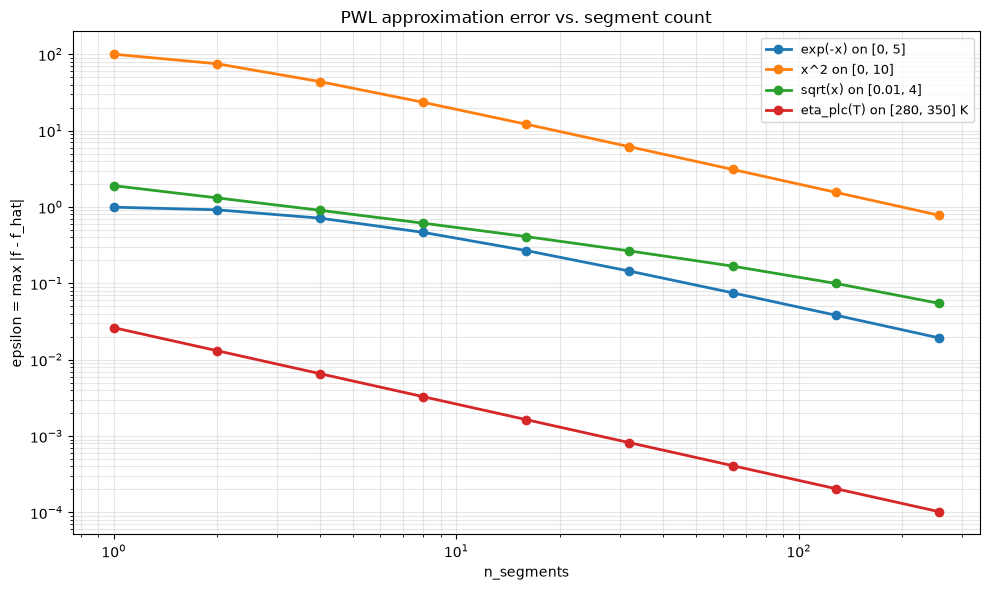

Log-log plot rendered.


In [4]:

fig, ax = plt.subplots(figsize=(10, 6))
for name, eps in results.items():
    ax.loglog(SEGMENTS, eps, marker="o", linewidth=2, label=name)

ax.set_xlabel("n_segments")
ax.set_ylabel("epsilon = max |f - f_hat|")
ax.set_title("PWL approximation error vs. segment count")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print("Log-log plot rendered.")



## Section 4 - Gate assertion

The gate is: epsilon decreases monotonically with n_segments. In
practice the correct statement is non-increasing, because a finite
sample grid can only weakly improve the bound. We assert
non-increasing with a small numerical tolerance, and additionally
confirm that the final epsilon is strictly smaller than the first
for every function in the sweep.


In [5]:

TOL = 1e-9
for name, eps in results.items():
    for i in range(1, len(eps)):
        delta = eps[i] - eps[i - 1]
        assert delta <= TOL, (
            f"epsilon increased for {name} at n={SEGMENTS[i]}: "
            f"{eps[i - 1]:.3e} -> {eps[i]:.3e}"
        )
    assert eps[-1] < eps[0], (
        f"Final epsilon not smaller than initial for {name}: "
        f"{eps[0]:.3e} -> {eps[-1]:.3e}"
    )

print("Monotonic non-increase: PASS for all four functions.")
print("Final < initial:        PASS for all four functions.")


Monotonic non-increase: PASS for all four functions.
Final < initial:        PASS for all four functions.



## Section 5 - Summary

The s3-6 gate is satisfied: epsilon decreases monotonically with
n_segments for every function in the sweep, and the per-function
epsilon tables are logged above. This closes the loop on the Stage B
error-tracking requirement from Section 34.2: any epsilon used in a
verification result is now backed by a numerical convergence
demonstration on the actual functions Stage B will encode.


In [6]:

print("Notebook 04 - PWL error convergence")
print("=" * 60)
for name, eps in results.items():
    ratio = eps[0] / max(eps[-1], 1e-30)
    print(
        f"{name:<28s}: eps(1) = {eps[0]:.3e}, "
        f"eps(256) = {eps[-1]:.3e}, ratio = {ratio:.1f}x"
    )
print()
print("ALL GATES PASS")


Notebook 04 - PWL error convergence
exp(-x) on [0, 5]           : eps(1) = 9.933e-01, eps(256) = 1.934e-02, ratio = 51.4x
x^2 on [0, 10]              : eps(1) = 1.000e+02, eps(256) = 7.797e-01, ratio = 128.3x
sqrt(x) on [0.01, 4]        : eps(1) = 1.900e+00, eps(256) = 5.481e-02, ratio = 34.7x
eta_plc(T) on [280, 350] K  : eps(1) = 2.625e-02, eps(256) = 1.025e-04, ratio = 256.0x

ALL GATES PASS
